In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Sklearn - evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')
print(f"Data shape: {df.shape}")
df.head()

Data shape: (499290, 257)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),City,County,Airport_Code,Weather_Timestamp,...,Astronomical_Twilight_night,Astronomical_Twilight_nan,weather_group_clear,weather_group_cloudy,weather_group_low_visibility,weather_group_other,weather_group_rain,weather_group_snow_ice,weather_group_storm,weather_group_nan
0,2,2019-10-29 13:16:54,2019-10-29 15:21:34,35.834797,-78.638512,0.000,5574,7666,6971,2019-10-29 12:51:00,...,False,False,False,True,False,False,False,False,False,False
1,2,2021-10-13 06:30:00,2021-10-13 06:59:15,36.088970,-96.011734,0.000,1896,1928,966,2021-10-13 06:29:00,...,False,False,False,False,False,False,True,False,False,False
2,2,2022-08-14 14:42:58,2022-08-14 16:27:58,33.537049,-86.794445,0.152,1143,3805,1434,2022-08-14 14:53:00,...,False,False,True,False,False,False,False,False,False,False
3,2,2021-06-25 19:13:44,2021-06-25 20:42:30,34.071722,-117.612886,0.869,1208,7010,2253,2021-06-25 18:53:00,...,False,False,True,False,False,False,False,False,False,False
4,2,2022-03-18 12:50:30,2022-03-18 13:13:00,40.324235,-76.790464,0.166,324,418,801,2022-03-18 12:56:00,...,False,False,True,False,False,False,False,False,False,False


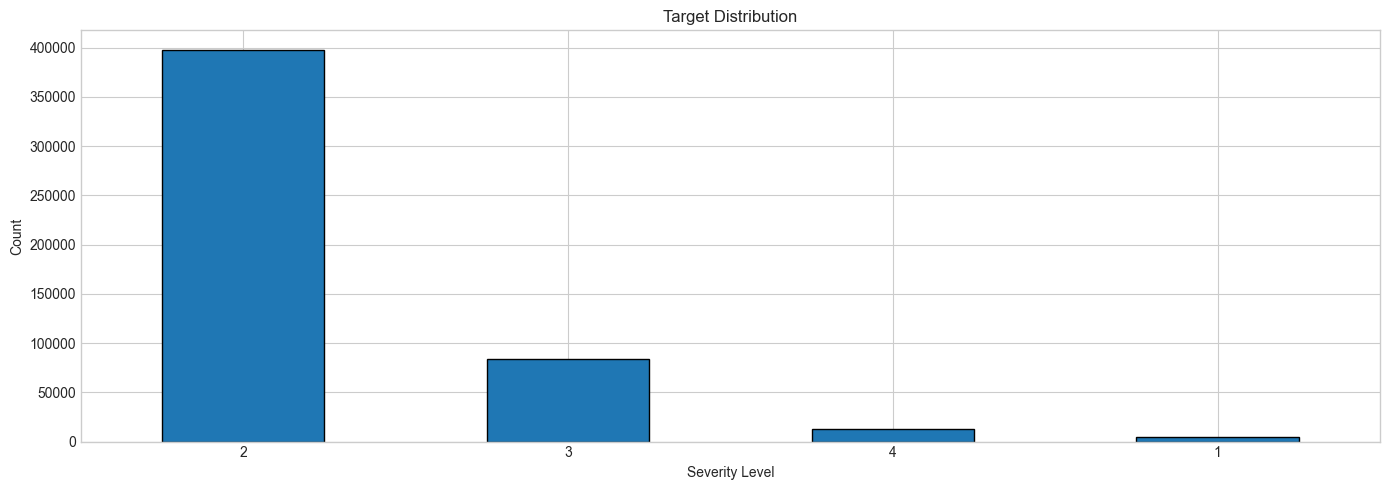

In [3]:
# Visualize the binned distribution
fig, ax = plt.subplots(1, 1, figsize=(14, 5))

# Binned category counts
df['Target'].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Count')
ax.set_title('Target Distribution')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [4]:
# Check class balance
class_counts = df['Target'].value_counts()
class_percentages = df['Target'].value_counts(normalize=True) * 100

print("Class Distribution:")
for cat in class_counts.index:
    print(f"{cat}: {class_counts[cat]} ({class_percentages[cat]:.1f}%)")

# Check for severe imbalance
min_class_pct = class_percentages.min()
if min_class_pct < 10:
    print(f"\nWarning: Smallest class is only {min_class_pct:.1f}% of data.")
    print("Consider adjusting your binning strategy.")
else:
    print(f"\nClass balance looks reasonable!")

Class Distribution:
2: 397669 (79.6%)
3: 84039 (16.8%)
4: 13229 (2.6%)
1: 4353 (0.9%)

Consider adjusting your binning strategy.


In [5]:
#400,000 rows with 252 features take a very long time to train

# for testing, manually create a balanced 20,000 rows dataset
'''
df_sample = df.groupby('Target', group_keys=False)\
              .apply(lambda x: x.sample(n=min(len(x), 4000), random_state=42))\
              .reset_index(drop=True)

df_sample.shape

df_sample['Target'].value_counts()
'''

"\ndf_sample = df.groupby('Target', group_keys=False)              .apply(lambda x: x.sample(n=min(len(x), 4000), random_state=42))              .reset_index(drop=True)\n\ndf_sample.shape\n\ndf_sample['Target'].value_counts()\n"

In [6]:
datetime_cols = df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns

print(datetime_cols)

Index([], dtype='object')


In [7]:
time_cols = df.columns[df.columns.str.contains('time', case=False)]

print(time_cols)

Index(['Start_Time', 'End_Time', 'Weather_Timestamp', 'Timezone_missing',
       'Timezone_us/central', 'Timezone_us/eastern', 'Timezone_us/mountain',
       'Timezone_us/pacific', 'Timezone_nan'],
      dtype='object')


In [8]:
X = df.drop(columns=['Severity', 'Target', 'Start_Time', 'End_Time', 'Weather_Timestamp']).copy()
y = df['Target']

In [9]:
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget classes: {y.unique().tolist()}")

Features shape: (499290, 252)
Target shape: (499290,)

Features used: ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'Airport_Code', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'duration_min', 'is_freezing', 'low_visibility', 'lat_bin', 'n_road_features', 'has_traffic_control', 'State_al', 'State_ar', 'State_az', 'State_ca', 'State_co', 'State_ct', 'State_dc', 'State_de', 'State_fl', 'State_ga', 'State_ia', 'State_id', 'State_il', 'State_in', 'State_ks', 'State_ky', 'State_la', 'State_ma', 'State_md', 'State_me', 'State_mi', 'State_mn', 'State_mo', 'State_ms', 'State_mt', 'State_nc', 'State_nd', 'State_ne', 'State_nh', 'State_nj', 'Sta

In [10]:
# TODO: Encode your target labels to numbers using LabelEncoder
#
# Steps:
# 1. Create a LabelEncoder instance
# 2. Fit and transform y to create y_encoded
#
# Hint: label_encoder.fit_transform(y)

# YOUR CODE HERE:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [11]:
# Verify encoding (run this to check)
print("Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

Label encoding:
1 -> 0
2 -> 1
3 -> 2
4 -> 3


In [12]:
# TODO: Split your data with stratification
#
# Requirements:
# - 80/20 split (test_size=0.2)
# - random_state=42 for reproducibility
# - stratify=y_encoded (THIS IS THE KEY DIFFERENCE FROM REGRESSION!)
#   This ensures each class is proportionally represented in train/test
#
# Store in: X_train, X_test, y_train, y_test

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=0.2, # 30% of data for testing
    random_state=42, # for reproducibility
    stratify=y_encoded # this is the key parameter for stratification
)

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

for k,v in class_weights.items():    
    print(f"{k}: {v:.2f}")

0: 28.67
1: 0.31
2: 1.49
3: 9.44


In [14]:
# Verify split and stratification
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f" {c} ({c/len(y_train)*100:.1f}%)")

Training set: 399432 samples
Test set: 99858 samples

Training class distribution:
 3483 (0.9%)
 318135 (79.6%)
 67231 (16.8%)
 10583 (2.6%)


In [15]:
# TODO: Scale your features using StandardScaler
#
# Same as regression:
# 1. Create StandardScaler instance
# 2. fit_transform on X_train
# 3. transform (only!) on X_test
#
# Store in: X_train_scaled, X_test_scaled

# YOUR CODE HERE:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
# Convert to DataFrame (helpful for later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

SELECTED_FEATURES = X.columns.tolist()
print("Features scaled successfully!")
print(f"Scaler fitted on {len(SELECTED_FEATURES)} features.")

Features scaled successfully!
Scaler fitted on 252 features.


In [17]:
#!pip install xgboost

In [18]:
# xgbclassifier clearly out-performs the other two models
# use xgboost to build and evaluate key matrics

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100, 
    max_depth=5, 
    #min_child_weight=5,
    gamma=1,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='mlogloss',
    random_state=42,
    objective='multi:softprob',
    num_class=4,
    scale_pos_weight=class_weights  # per class tuning
)

model_name = 'Gradient Boosting'



In [19]:
model.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [20]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [21]:
print (f"'Train Accuracy': {accuracy_score(y_train, y_train_pred):.4f}")

'Train Accuracy': 0.8397


In [22]:
print (f"'Test Accuracy': {accuracy_score(y_test, y_test_pred):.4f}")

'Test Accuracy': 0.8378


In [23]:
print (f"'Precision (weighted)': {precision_score(y_test, y_test_pred, average='weighted'):.4f}")

'Precision (weighted)': 0.8201


In [24]:
print (f"'Recall (weighted)': {recall_score(y_test, y_test_pred, average='weighted'):.4f}")

'Recall (weighted)': 0.8378


In [25]:
print (f"'F1 (weighted)': {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

'F1 (weighted)': 0.8122


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_test_pred, target_names=["1", "2", "3", "4"]))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.73      0.15      0.25       870
           2       0.85      0.96      0.91     79534
           3       0.70      0.39      0.50     16808
           4       0.62      0.11      0.18      2646

    accuracy                           0.84     99858
   macro avg       0.72      0.40      0.46     99858
weighted avg       0.82      0.84      0.81     99858

[[  132   706    32     0]
 [   32 76747  2650   105]
 [   13 10228  6498    69]
 [    5  2252   108   281]]


### Model 1: Traffic Accident Severity — Traditional ML

- Multi-class classification: predict accident severity (1-4 scale)
- This dataset has significant class imbalance — your approach to handling it will be a key evaluation criterion. **Weighted F1 is the real evaluation metric**, not accuracy.
- Use classical ML algorithms (XGBoost, Random Forest, Gradient Boosting, etc.)
- Must be interpretable — city planners need to understand WHY an intersection is flagged as high-risk
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 80%, weighted F1 > 0.70
- **Required:** SHAP or feature importance analysis — which factors most predict severe accidents?

In [27]:

################################# Feature Importance Analysis and Plot #########################################
#print(model.feature_importances_)



Top 30 most important features:
  has_traffic_control: 0.1094
  Distance(mi): 0.0493
  Traffic_Signal: 0.0472
  Crossing: 0.0404
  duration_min: 0.0349
  State_ga: 0.0250
  State_mo: 0.0233
  Timezone_us/pacific: 0.0207
  State_ca: 0.0196
  State_il: 0.0191
  Weather_Condition_clear: 0.0191
  Weather_Condition_fair: 0.0176
  State_sc: 0.0174
  Timezone_us/eastern: 0.0167
  State_ok: 0.0159
  is_weekend: 0.0155
  Wind_Chill(F): 0.0149
  State_co: 0.0142
  State_pa: 0.0133
  Airport_Code: 0.0128
  Weather_Condition_overcast: 0.0124
  day_of_week: 0.0120
  County: 0.0117
  Junction: 0.0111
  State_az: 0.0107
  State_mn: 0.0107
  Start_Lng: 0.0105
  State_wa: 0.0104
  Nautical_Twilight_night: 0.0102
  Railway: 0.0102


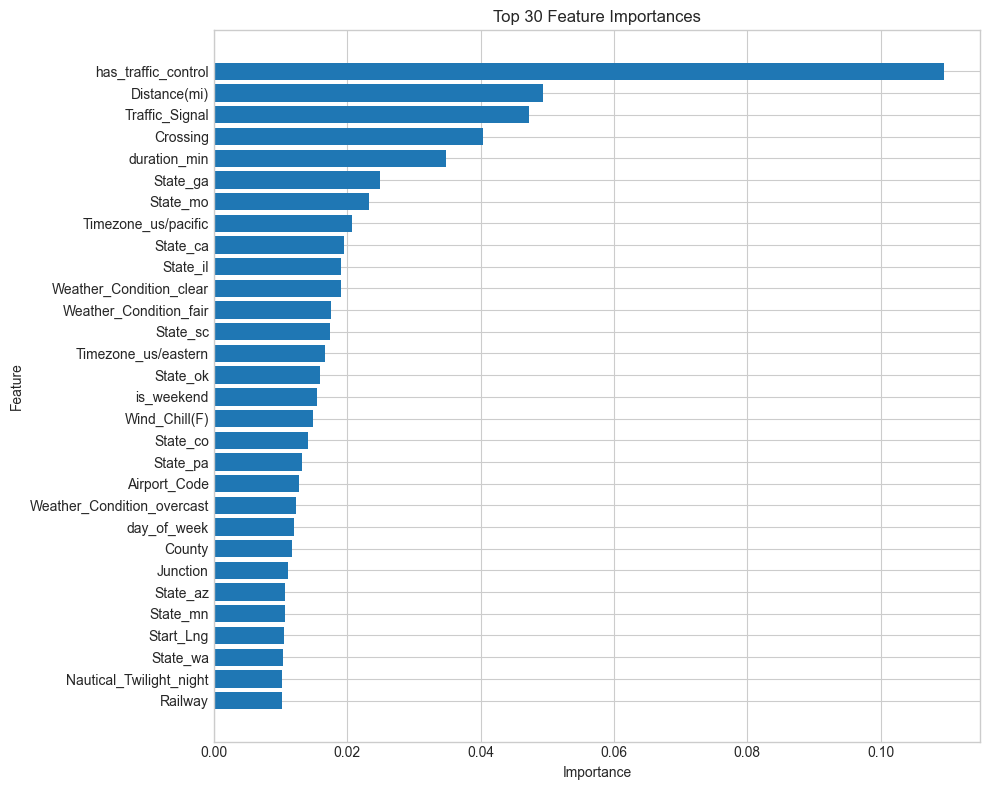

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# get importances
importances = model.feature_importances_

# if X_train is a DataFrame, use its column names
feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# keep top 30
top_n = 30
feat_imp = feat_imp.sort_values("importance", ascending=False).head(top_n)

feat_imp1 = feat_imp.sort_values("importance", ascending=True).head(top_n)

print("\nTop 30 most important features:")
for i, row in feat_imp1.tail(30).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


# plot
plt.figure(figsize=(10, 8))
plt.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances")
plt.tight_layout()
plt.show()

In [29]:

################################# SHAP Explainer and Plot #########################################
!pip install shap



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import shap

# create explainer (TreeExplainer is optimized for XGBoost)
explainer = shap.TreeExplainer(model)

# compute SHAP values (use a sample for speed if needed)
X_sample = X_train.sample(100000, random_state=42)

shap_values = explainer.shap_values(X_sample)

*****************************
Traffic Severity Level: 1


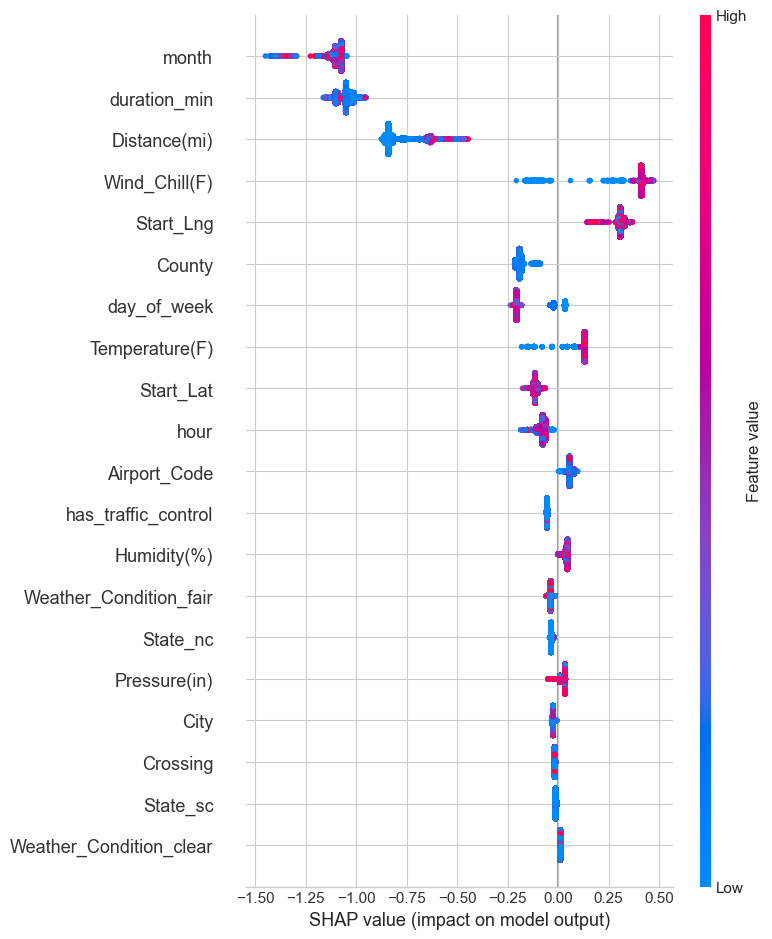

*****************************
Traffic Severity Level: 2


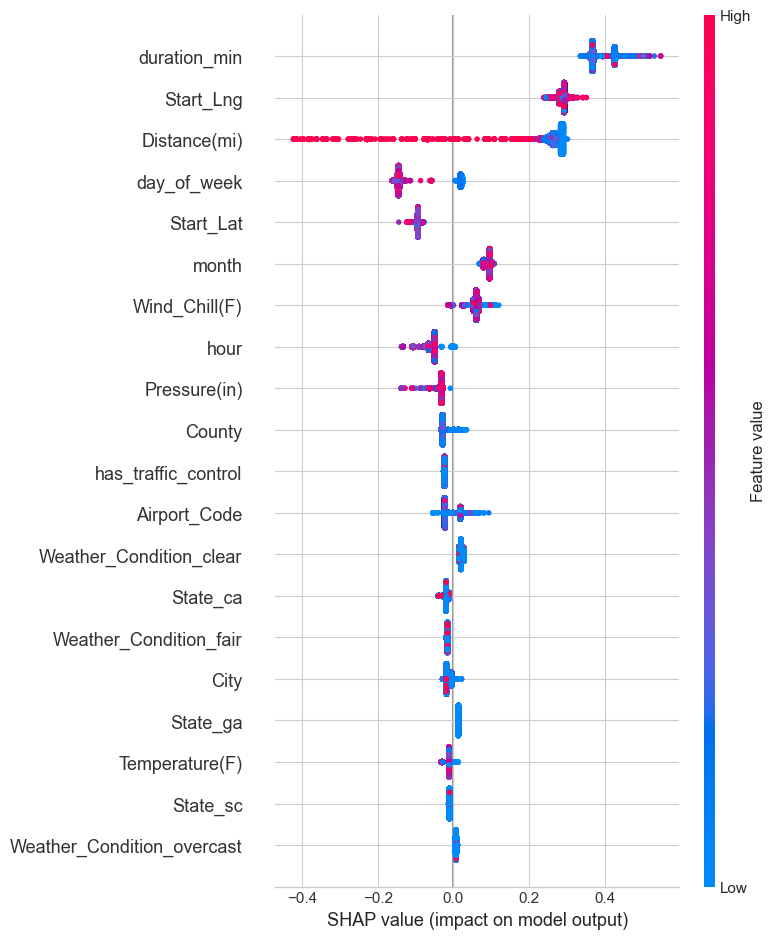

*****************************
Traffic Severity Level: 3


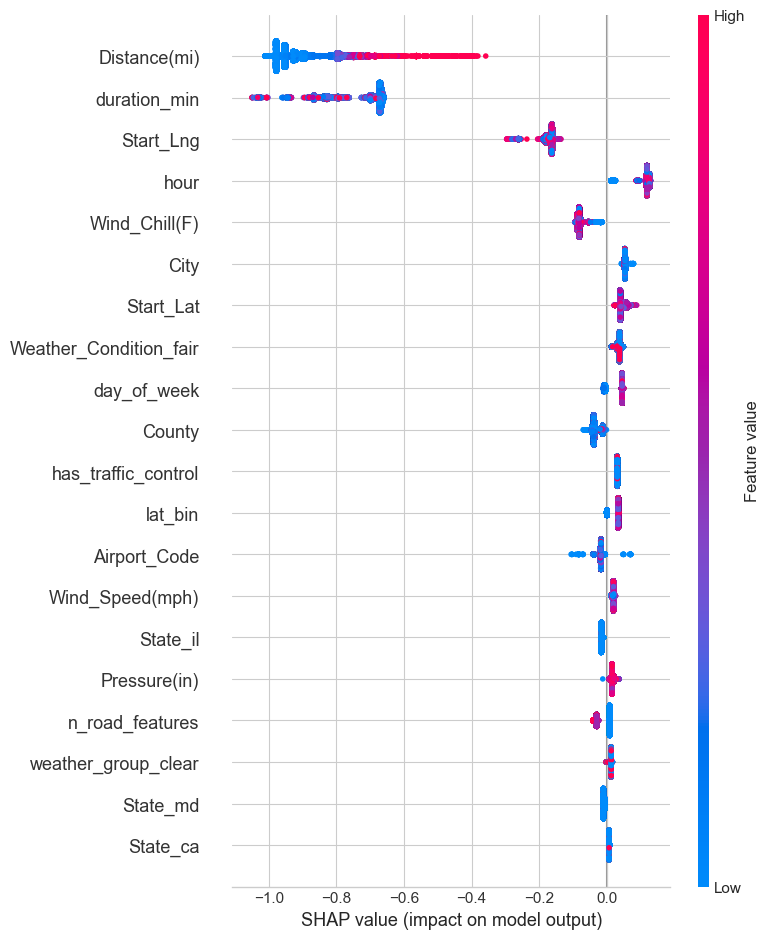

*****************************
Traffic Severity Level: 4


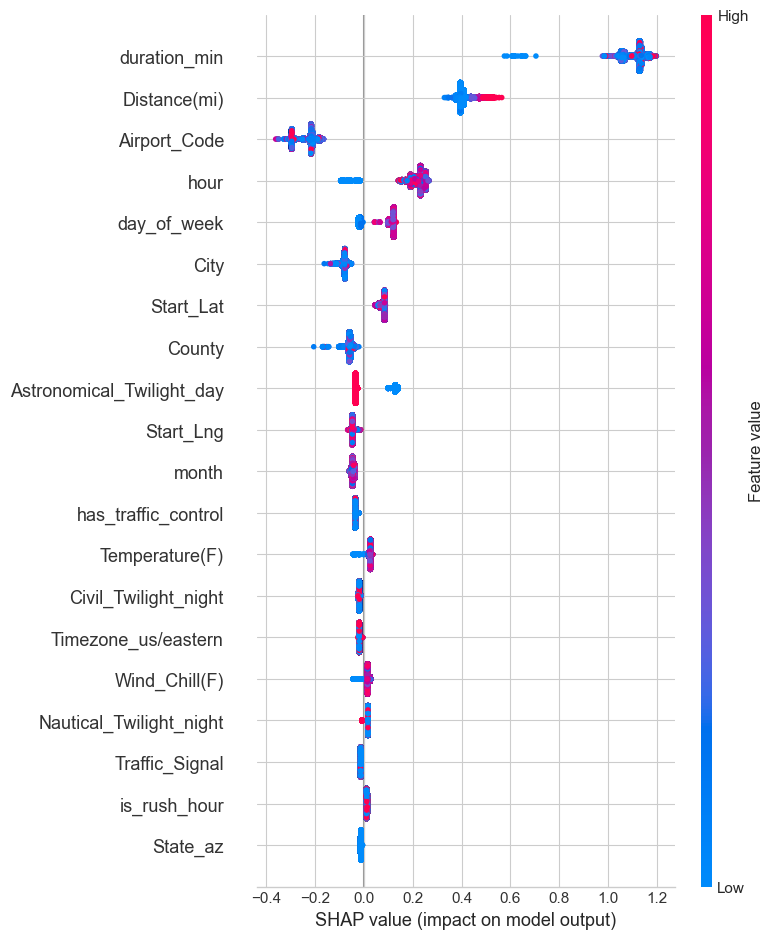

In [31]:
# Top drivers for all classes
for i in range(4):
    print('*****************************')
    print(f"Traffic Severity Level: {i+1}")
    
    shap.summary_plot(shap_values[:,:,i], X_sample)

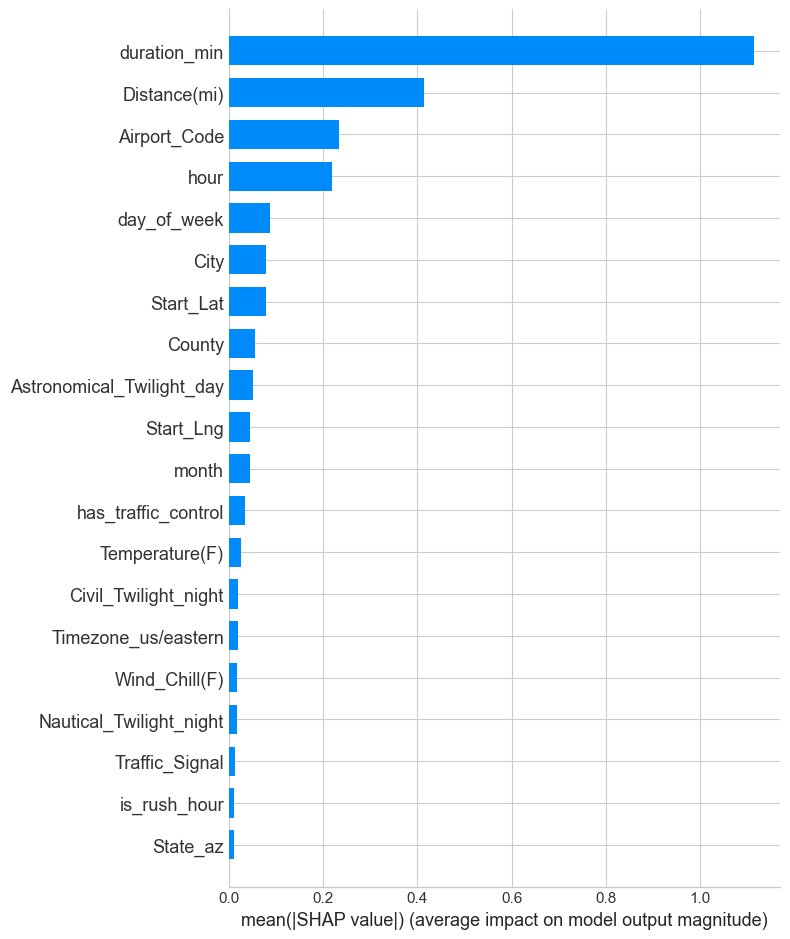

In [32]:
# Top drivers for the most severe accidents (level 4) in clear bar chart
shap.summary_plot(shap_values[:,:,3], X_sample, plot_type="bar")